## Shapely/unary_union/Polygon/Multipolygon Tutorial

In [1]:
from shapely.constructive import make_valid
from shapely.geometry import Polygon
from shapely.ops import unary_union
import matplotlib.pyplot as plt


In [2]:
def plot_geom(ax, geom, title):
    if geom.geom_type == "Polygon":
        x, y = geom.exterior.xy
        ax.fill(x, y, alpha=0.5)
    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            x, y = poly.exterior.xy
            ax.fill(x, y, alpha=0.5)

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.grid(True)


# Fall 1: Ergibt Polygon

In [3]:
p1 = Polygon([(0, 0), (2, 0), (2, 2), (0, 2)])
p2 = Polygon([(1, 1), (3, 1), (3, 3), (1, 3)])

u1 = unary_union([p1, p2])
print(u1.geom_type)


Polygon


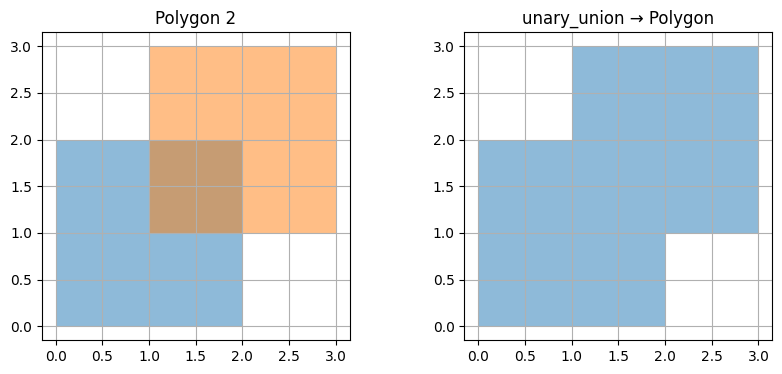

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

plot_geom(ax[0], p1, "Polygon 1")
plot_geom(ax[0], p2, "Polygon 2")

plot_geom(ax[1], u1, "unary_union → Polygon")

plt.show()


## Fall 2: Ergibt Multipolygon

In [5]:
p3 = Polygon([(0, 0), (2, 0), (2, 2), (0, 2)])
p4 = Polygon([(4, 0), (6, 0), (6, 2), (4, 2)])

u2 = unary_union([p3, p4])
print(u2.geom_type)


MultiPolygon


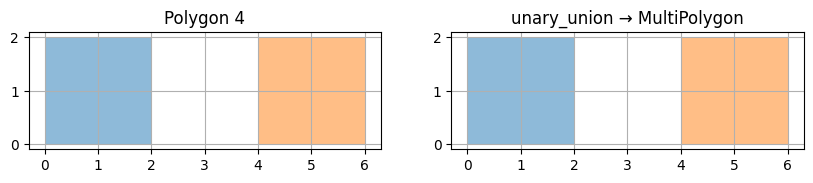

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

plot_geom(ax[0], p3, "Polygon 3")
plot_geom(ax[0], p4, "Polygon 4")

plot_geom(ax[1], u2, "unary_union → MultiPolygon")

plt.show()


## Zusatz: Berühren reicht auch aus!

In [8]:
p5 = Polygon([(0, 0), (2, 0), (2, 2), (0, 2)])
p6 = Polygon([(2, 0), (4, 0), (4, 2), (2, 2)])

u3 = unary_union([p5, p6])
print(u3.geom_type)

Polygon


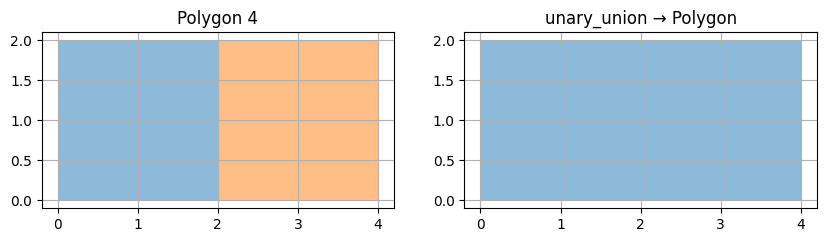

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

plot_geom(ax[0], p5, "Polygon 3")
plot_geom(ax[0], p6, "Polygon 4")

plot_geom(ax[1], u3, "unary_union → Polygon")

plt.show()

## Meine Methode genauer betrachet (mind. Überlappung dann union)

In [10]:
def union_if_overlap(p1, p2, threshold=0.8):
    overlap_ratio = p2.intersection(p1).area / p2.area

    if overlap_ratio >= threshold:
        result = unary_union([p1, p2])
        action = f"Union durchgeführt ({overlap_ratio:.2f})"
    else:
        result = [p1, p2]
        action = f"Keine Union ({overlap_ratio:.2f})"

    return result, action

In [11]:
p1 = Polygon([(0, 0), (4, 0), (4, 4), (0, 4)])
p2 = Polygon([(1, 1), (3, 1), (3, 3), (1, 3)])  # komplett in p1

res_A, msg_A = union_if_overlap(p1, p2)
print(msg_A)


Union durchgeführt (1.00)


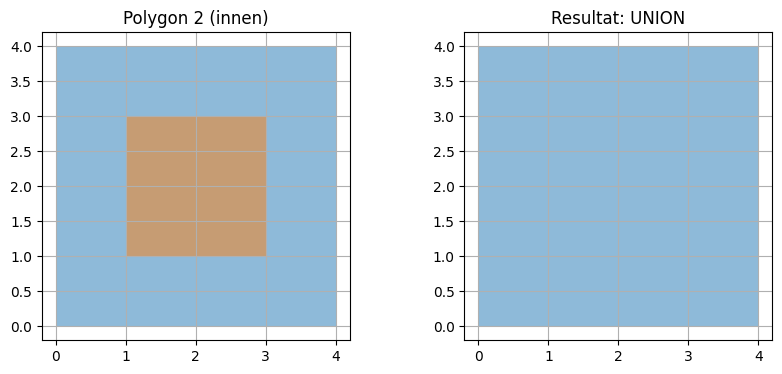

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

plot_geom(ax[0], p1, "Polygon 1")
plot_geom(ax[0], p2, "Polygon 2 (innen)")

plot_geom(ax[1], res_A, "Resultat: UNION")

plt.show()


## Beispiel keine Überlappung:

In [14]:
p3 = Polygon([(0, 0), (4, 0), (4, 4), (0, 4)])
p4 = Polygon([(3, 3), (5, 3), (5, 5), (3, 5)])  # kleine Überlappung
res_B, msg_B = union_if_overlap(p3, p4)
print(msg_B)


Keine Union (0.25)


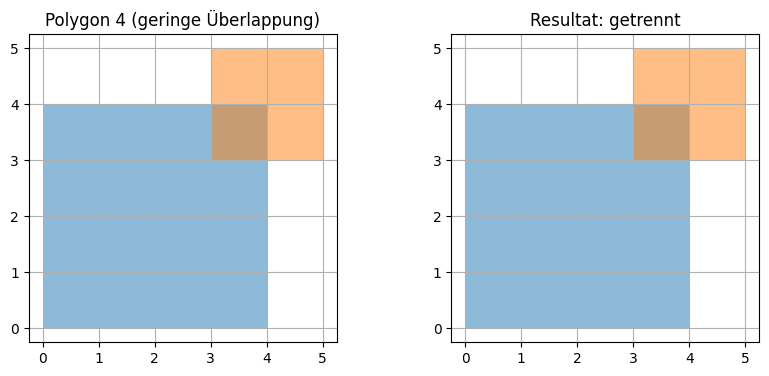

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

plot_geom(ax[0], p3, "Polygon 3")
plot_geom(ax[0], p4, "Polygon 4 (geringe Überlappung)")

plot_geom(ax[1], p3, "Resultat: getrennt")
plot_geom(ax[1], p4, "Resultat: getrennt")

plt.show()


## Ein Beispiel mit echter YOLO-Maske, die sich selbst schneidet (invalides Polygon)

In [3]:
# http://shapely.readthedocs.io/en/stable/reference/shapely.buffer.html
#https://gis.stackexchange.com/questions/356546/shapely-buffer0-returns-an-empty-polygoncoordinates-and-discard-the-main
# make_valid hat aus irgendeinem Grund nicht funktioniert, daher buffer(0) als Alternative
# https://gis.stackexchange.com/questions/430384/using-shapely-methods-explain-validity-and-make-valid-on-shapefile
# buffer(0) erzeugt einen Puffer von 0, repariert dadurch ungültige Polygone, kann aber auch MultiPolygon erzeugen, wenn das ursprüngliche Polygon z.B. eine Selbstüberschneidung hatte

from pathlib import Path
import cv2
import numpy as np
from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely import is_valid_reason
from ultralytics import YOLO  # falls du YOLO benutzt

own_data_model = YOLO("trained_yolo_fuer_beweis/weigths_two/best.pt")
#img = cv2.imread("webanwendungTest2.jpg")
img = cv2.imread("schraege_zeile.jpg")
res = own_data_model.predict(img)


0: 1024x768 3 textlines, 1389.3ms
Speed: 106.9ms preprocess, 1389.3ms inference, 228.9ms postprocess per image at shape (1, 3, 1024, 768)


In [2]:
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import json

polygons = []

# Klassen-Namen aus dem Modell
class_names = res[0].names

# YOLO Masken -> Shapely Polygone
for idx, (mask, cls_id) in enumerate(zip(res[0].masks.xy, res[0].boxes.cls)):
    poly = Polygon(mask)


    polygons.append({
        "id": idx,
        "class": class_names[int(cls_id)],
        "polygon": poly
    })

print(f"Extrahierte Polygone: {len(polygons)}")

Extrahierte Polygone: 3


## Polygone anzeigen
- man erkennt schon, dass Polygon 0 aus mehreren Masken besteht

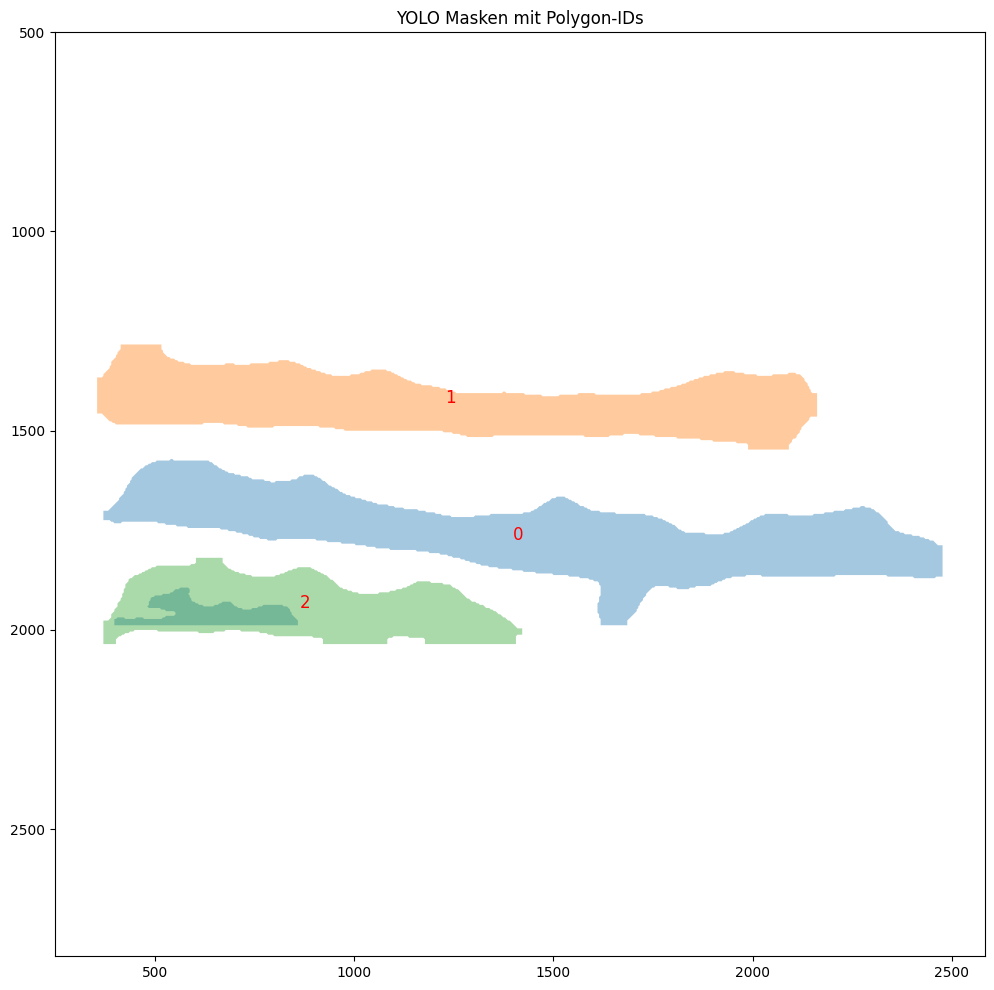

In [9]:
plt.figure(figsize=(12, 12))

for p in polygons:
    x, y = p["polygon"].exterior.xy
    plt.fill(x, y, alpha=0.4)
    cx, cy = p["polygon"].centroid.coords[0]
    plt.text(cx, cy, f'{p["id"]}', color="red", fontsize=12)

plt.gca().invert_yaxis()
plt.axis("equal")
plt.title("YOLO Masken mit Polygon-IDs")
plt.show()

In [ ]:
export = [
    {
        "id": p["id"],
        "class": p["class"],
        "polygon": list(map(lambda xy: [float(xy[0]), float(xy[1])],
                            p["polygon"].exterior.coords))
    }
    for p in polygons
]

with open("debug_polygons.json", "w") as f:
    json.dump(export, f, indent=2)

print("debug_polygons.json geschrieben")

## Validität der Polygone prüfen

In [10]:
from shapely.validation import explain_validity
mask0 = res[0].masks.xy[0]
poly0 = Polygon(mask0)
print(explain_validity(poly0))  # Um herauszufinden, warum Polygon ungültig ist
print("Valid:", poly0.is_valid)
print("Area:", poly0.area)

Self-intersection[582.749938964844 1893.93737792969]
Valid: False
Area: 328589.7564382553


## Problemstelle ist polygon 0, dieses schneidet sich anscheinend selber:

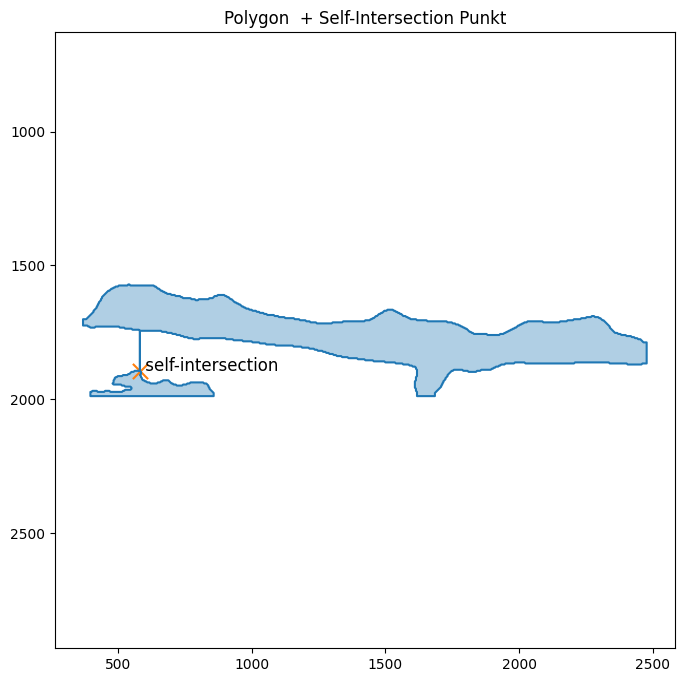

In [11]:
from shapely.geometry import Polygon, Point
import matplotlib.pyplot as plt

mask0 = res[0].masks.xy[0]
poly0 = Polygon(mask0)
#mask9 = res[0].masks.xy[2]
#poly9 = Polygon(mask9)

# Problemstelle aus explain_validity
p_bad = Point(582.749938964844, 1893.93737792969)

plt.figure(figsize=(8, 8))
x, y = poly0.exterior.xy
plt.fill(x, y, alpha=0.35)
plt.plot(x, y)  # Rand

# Problemstelle markieren
plt.scatter([p_bad.x], [p_bad.y], s=120, marker="x")
plt.text(p_bad.x, p_bad.y, " self-intersection", fontsize=12)

plt.gca().invert_yaxis()  # Bild-Koordinaten wie OpenCV/YOLO
plt.axis("equal")
plt.title("Polygon  + Self-Intersection Punkt")
#plt.grid(True)
plt.savefig("polygon_self_intersection.png", dpi=200, bbox_inches="tight")
plt.show()


## Lösung: buffer(0) → repariert ungültige Polygone, kann aber auch MultiPolygon erzeugen

buffer(0) hat 2 Polygone erzeugt


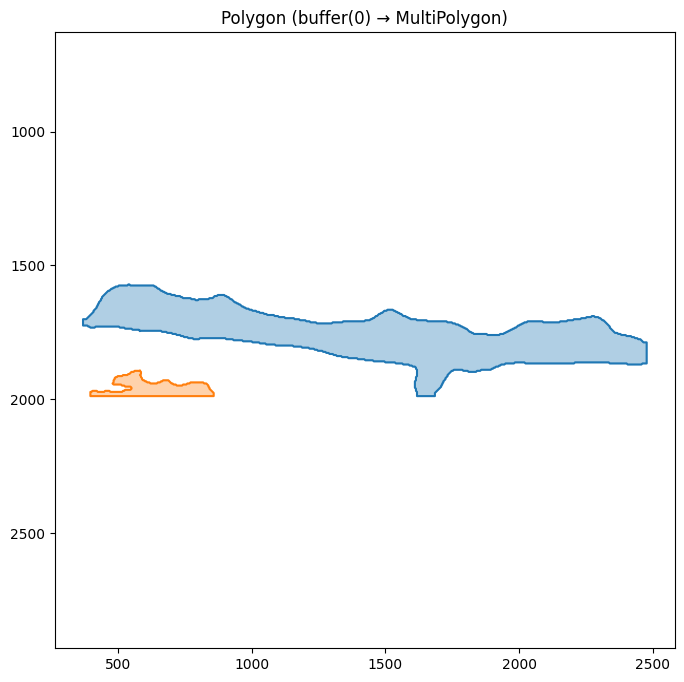

In [18]:
from shapely.geometry import Polygon, Point, MultiPolygon
import matplotlib.pyplot as plt

mask0 = res[0].masks.xy[0]
poly0 = Polygon(mask0)

poly0 = poly0.buffer(0)  # kann Polygon ODER MultiPolygon werden

plt.figure(figsize=(8, 8))

def draw_polygon(p, color="C0"):
    x, y = p.exterior.xy
    plt.fill(x, y, alpha=0.35, color=color)
    plt.plot(x, y, color=color)

if poly0.geom_type == "Polygon":
    draw_polygon(poly0)

elif poly0.geom_type == "MultiPolygon":
    print(f"buffer(0) hat {len(poly0.geoms)} Polygone erzeugt")
    for i, p in enumerate(poly0.geoms):
        draw_polygon(p, color=f"C{i}")

plt.gca().invert_yaxis()
plt.axis("equal")
plt.title("Polygon (buffer(0) → MultiPolygon)")
#plt.grid(True)
plt.savefig("polygon_buffer_multipolygon.png", dpi=200, bbox_inches="tight")
plt.show()


## Wenn buffer(0) ein MultiPolygon erzeugt, dann das größte Polygon auswählen, da die kleineren oft nur fehlerhafte Masken-Teile sind

Polygon-Typ nach buffer(0): MultiPolygon
Polygon-Typ nach Auswahl größtes Polygon: Polygon


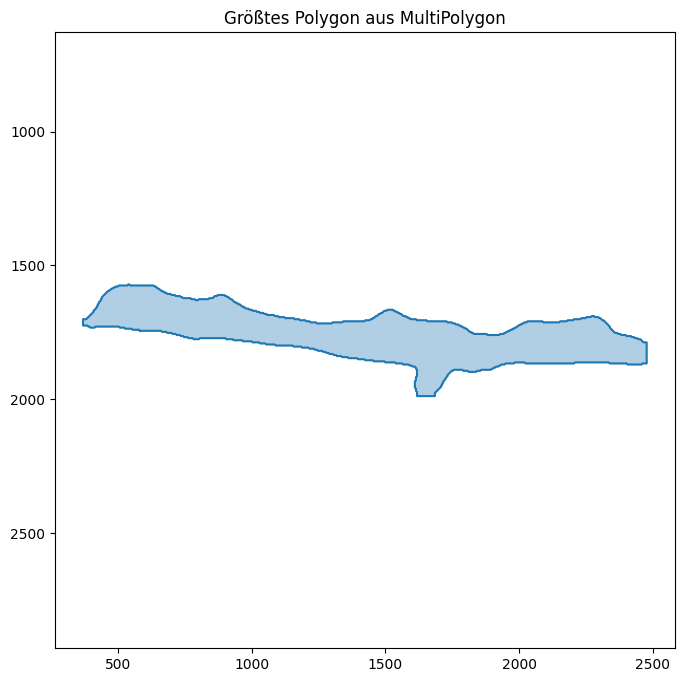

In [19]:
print(f"Polygon-Typ nach buffer(0): {poly0.geom_type}")

poly0 = max(poly0.geoms, key=lambda p: p.area)  # größtes Polygon auswählen

print(f"Polygon-Typ nach Auswahl größtes Polygon: {poly0.geom_type}")

plt.figure(figsize=(8, 8))
x, y = poly0.exterior.xy
plt.fill(x, y, alpha=0.35, color="C0")
plt.plot(x, y, color="C0")
plt.gca().invert_yaxis()
plt.axis("equal")
plt.title("Größtes Polygon aus MultiPolygon")
plt.savefig("largest_polygon.png", dpi=200, bbox_inches="tight")
plt.show()